# Exploratory Data Analysis

## Movie Sentiment Analysis

Data Set link : https://ai.stanford.edu/~amaas/data/sentiment/

Kaggle Dataset Link : https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
url_path = "data/IMDB Dataset.csv"
df_original =pd.read_csv(url_path)
df_original.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df = df_original.copy(deep=True)
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## Basic Info

In [4]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 63.6 MB


In [6]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [7]:
50000-49582 # no of duplicate rows

418

In [8]:
df['sentiment'].value_counts()

sentiment
positive    25000
negative    25000
Name: count, dtype: int64

## Descriptive Stats

In [9]:
# summary Statistics

df["review_char_len"] = df["review"].apply(len)
df["review_word_len"] = df['review'].apply(lambda x: len(x.split()))

# Description

print(df[['review_char_len', "review_word_len"]].describe())

       review_char_len  review_word_len
count     50000.000000     50000.000000
mean       1309.431020       231.156940
std         989.728014       171.343997
min          32.000000         4.000000
25%         699.000000       126.000000
50%         970.000000       173.000000
75%        1590.250000       280.000000
max       13704.000000      2470.000000


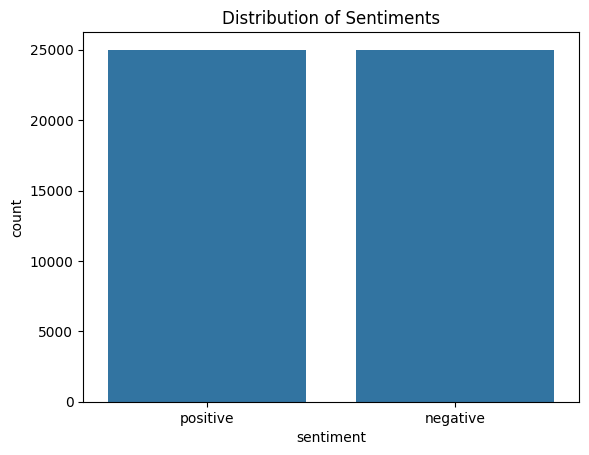

In [10]:
# histogram of sentiment

# Sentiment distribution
sns.countplot(x='sentiment', data=df)
plt.title("Distribution of Sentiments")
plt.show()

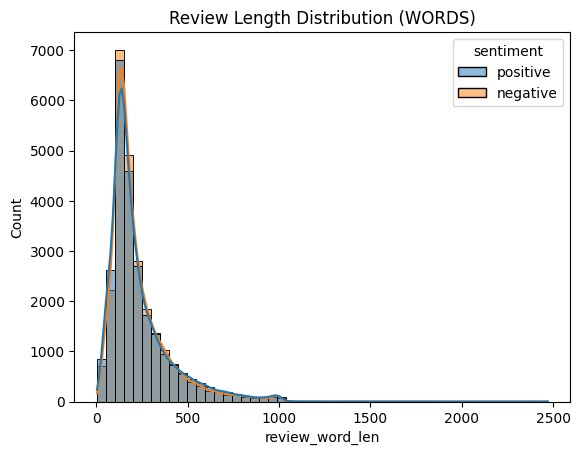

In [11]:
## histogram of the review word length
sns.histplot(data=df, x='review_word_len', bins=50, hue='sentiment', kde=True)
plt.title("Review Length Distribution (WORDS)")
plt.show()

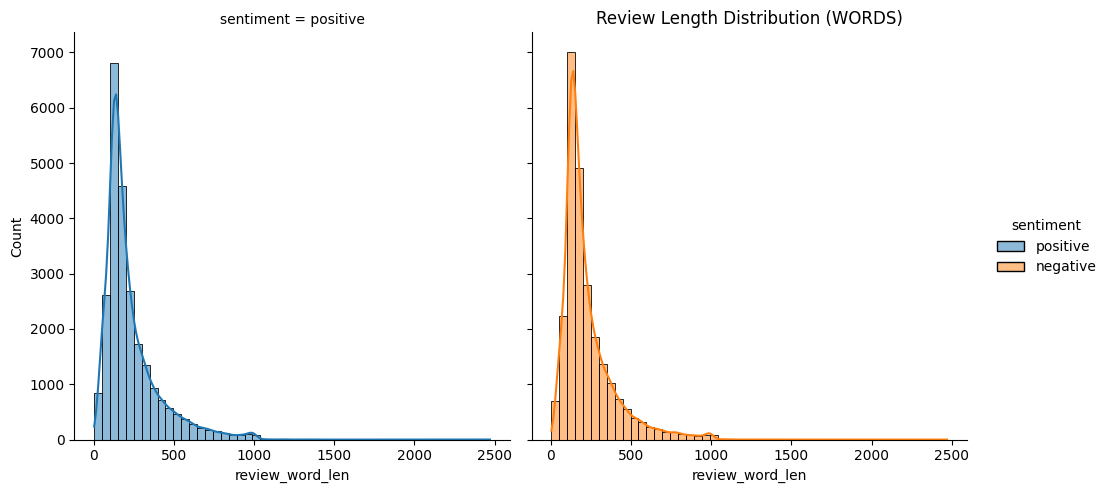

In [12]:
## distribution of the review word length
sns.displot(data=df, x='review_word_len',col='sentiment', bins=50, hue='sentiment', kde=True, )
plt.title("Review Length Distribution (WORDS)")
plt.show()

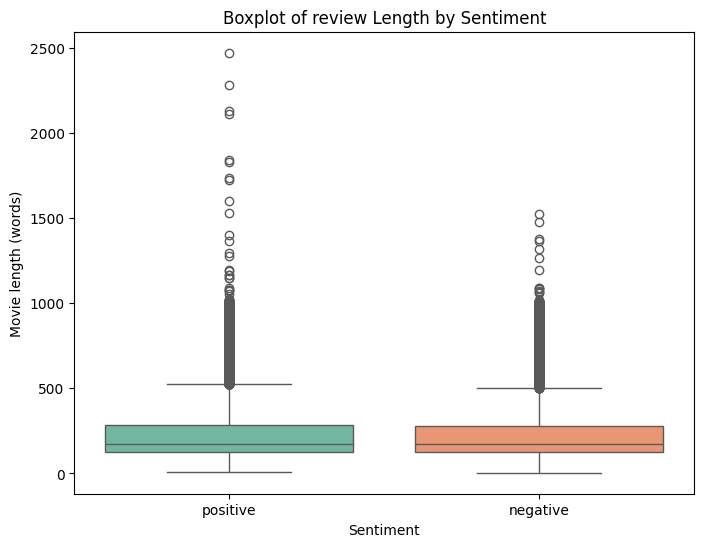

In [13]:
## Box plot of review length by sentiment

plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data = df, palette="Set2", hue= "sentiment")
plt.title("Boxplot of review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Movie length (words)")
plt.show()

## Removing Outliers with IQR


In [14]:
Q1 = df["review_word_len"].quantile(0.25)
Q3 = df["review_word_len"].quantile(0.75)
IQR = Q3-Q1
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 * IQR
outliers = df[(df["review_word_len"] < lower_fence) | (df["review_word_len"] > upper_fence)]
outliers

,review,sentiment,review_char_len,review_word_len
26,"""The Cell"" is an exotic masterpiece, a dizzyin...",positive,3149,570
29,'War movie' is a Hollywood genre that has been...,positive,3791,615
33,One of the most significant quotes from the en...,positive,4009,652
48,Preston Sturgis' THE POWER AND THE GLORY was u...,positive,3975,707
51,"***SPOILERS*** All too, in real life as well a...",positive,3371,621
...,...,...,...,...
49946,One of the greatest lessons I ever had in how ...,negative,2901,535
49948,"It is the early morning of our discontent, and...",negative,5847,986
49954,Why is it that every time I mention this movie...,negative,2789,532
49959,"My thoughts on the movie, 9<br /><br />It was ...",negative,3560,625


In [15]:
print("Number of outliers:", outliers.shape[0])

Number of outliers: 3708


In [16]:
outliers.describe()

,review_char_len,review_word_len
count,3708.000000,3708.000000
mean,4002.184736,698.197950
std,965.907822,164.958103
min,2599.000000,512.000000
25%,3267.750000,569.000000
50%,3749.500000,655.000000
75%,4559.250000,793.000000
max,13704.000000,2470.000000


In [17]:
# FE STEP
df_clean_from_iqr = df[(df['review_word_len'] >= lower_fence) & (df['review_word_len'] <= upper_fence)]
print("Orignal Data :", df.shape[0])
print("Cleaned Data :", df_clean_from_iqr.shape[0])

Orignal Data : 50000
Cleaned Data : 46292


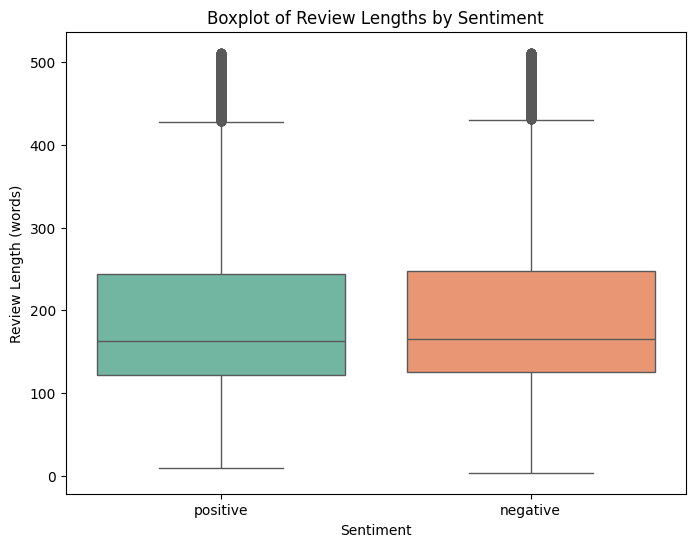

In [18]:
# Boxplot of Review Length by Sentiment
plt.figure(figsize=(8,6))
sns.boxplot(x="sentiment", y="review_word_len", data=df_clean_from_iqr, palette="Set2", hue="sentiment")
plt.title("Boxplot of Review Lengths by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (words)")
plt.show()

In [19]:
df_clean_from_iqr.head()

,review,sentiment,review_char_len,review_word_len
0,One of the other reviewers has mentioned that ...,positive,1761,307
1,A wonderful little production. <br /><br />The...,positive,998,162
2,I thought this was a wonderful way to spend ti...,positive,926,166
3,Basically there's a family where a little boy ...,negative,748,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230


In [20]:
# how many positive words in a positive case -->
# how many negative words in a negative case -->

### Most Common words (Positive VS Negative)

In [22]:
#!pip install nltk

In [23]:
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords

In [24]:
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Alfred\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [25]:
len(stop_words)

198

In [26]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [31]:
# Lowercase and remove symbols from the review not alphabet and br

def preprocess_text(text):
    # Lowercase & remove non-alphabetic characters
    words = re.findall(r'\b[a-z]+\b', text.lower())
    ##print(words)
    return [w for w in words if w not in stop_words and w!="br"]

In [29]:
# example
preprocess_text("<br> hello how are you !?")

['br', 'hello', 'how', 'are', 'you']


['hello']

In [32]:
# Separate reviews by sentiment
pos_reviews = df[df['sentiment']=="positive"]['review'].apply(preprocess_text)
neg_reviews = df[df['sentiment']=="negative"]['review'].apply(preprocess_text)

In [33]:
type(pos_reviews)

pandas.Series

In [34]:
# Flatten lists
pos_words = [word for review in pos_reviews for word in review]
neg_words = [word for review in neg_reviews for word in review]

In [38]:
# Get most common words
pos_common = Counter(pos_words).most_common(30)
neg_common = Counter(neg_words).most_common(30)

In [39]:
print("Top 20 Positive Words:", pos_common)
print("Top 20 Negative Words:", neg_common)

Top 20 Positive Words: [('film', 42110), ('movie', 37854), ('one', 27320), ('like', 17714), ('good', 15025), ('great', 12964), ('story', 12934), ('time', 12752), ('well', 12729), ('see', 12276), ('also', 10793), ('really', 10739), ('would', 10595), ('even', 9617), ('first', 9230), ('much', 9201), ('people', 8719), ('love', 8692), ('best', 8510), ('get', 8285), ('life', 8137), ('way', 7865), ('many', 7627), ('films', 7601), ('made', 7351), ('think', 7208), ('two', 7161), ('characters', 7103), ('movies', 6996), ('character', 6925)]
Top 20 Negative Words: [('movie', 50117), ('film', 37595), ('one', 26283), ('like', 22458), ('even', 15254), ('good', 14728), ('bad', 14726), ('would', 14007), ('time', 12358), ('really', 12355), ('see', 10753), ('story', 10185), ('get', 10136), ('much', 10117), ('people', 9469), ('make', 9355), ('could', 9300), ('made', 8801), ('well', 8539), ('first', 8353), ('movies', 8313), ('plot', 8214), ('acting', 8087), ('way', 7780), ('characters', 7353), ('watch', 72

In [37]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
    # CountVectorizer
    # (2,2) -> only bigrams
    # (3,3) -> only trigram
    # (1,2) --> mix of uni and bigrams
    # (2,3) --> bit + tri
    # (1,3) --> uni + bi + trigrams
    # similar to python range but without exclusion

In [40]:
def get_top_ngrams(words_list, ngram_range=(2,2), top_n=10):
    vec = CountVectorizer(ngram_range=ngram_range)
    bag = vec.fit_transform([' '.join(words_list)])
    sum_words = bag.sum(axis=0)
    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    sorted_words = sorted(words_freq, key=lambda x: x[1], reverse=True)
    return sorted_words[:top_n]

In [41]:
# Top bigrams
print("Top Positive Bigrams:", get_top_ngrams(pos_words, (2,2)))
print("Top Negative Bigrams:", get_top_ngrams(neg_words, (2,2)))

Top Positive Bigrams: [('one best', np.int64(1680)), ('even though', np.int64(1099)), ('ever seen', np.int64(976)), ('first time', np.int64(960)), ('new york', np.int64(855)), ('special effects', np.int64(806)), ('see movie', np.int64(784)), ('must see', np.int64(778)), ('real life', np.int64(761)), ('years ago', np.int64(741))]
Top Negative Bigrams: [('ever seen', np.int64(1734)), ('special effects', np.int64(1443)), ('waste time', np.int64(1437)), ('looks like', np.int64(1234)), ('low budget', np.int64(1229)), ('much better', np.int64(1009)), ('one worst', np.int64(964)), ('look like', np.int64(945)), ('bad movie', np.int64(927)), ('year old', np.int64(914))]


In [47]:
# Top trigrams
print("Top Positive trigrams:", get_top_ngrams(pos_words, (3,3)))
print("Top Negative trigrams:", get_top_ngrams(neg_words, (3,3)))

Top Positive trigrams: [('new york city', np.int64(195)), ('world war ii', np.int64(167)), ('one best movies', np.int64(144)), ('based true story', np.int64(135)), ('movie ever seen', np.int64(134)), ('one best films', np.int64(132)), ('first time saw', np.int64(115)), ('movies ever seen', np.int64(112)), ('films ever made', np.int64(99)), ('well worth watching', np.int64(95))]
Top Negative trigrams: [('worst movie ever', np.int64(459)), ('movie ever seen', np.int64(394)), ('one worst movies', np.int64(311)), ('worst movies ever', np.int64(282)), ('movies ever seen', np.int64(268)), ('worst film ever', np.int64(202)), ('waste time money', np.int64(181)), ('one worst films', np.int64(169)), ('film ever seen', np.int64(166)), ('movie ever made', np.int64(155))]


In [48]:
# Top trigrams
print("Top Positive tetragrams:", get_top_ngrams(pos_words, (4,4)))
print("Top Negative tetragrams:", get_top_ngrams(neg_words, (4,4)))

Top Positive tetragrams: [('one best movies ever', np.int64(51)), ('one best movies seen', np.int64(36)), ('best movie ever seen', np.int64(32)), ('one best films seen', np.int64(31)), ('vote eight title brazil', np.int64(30)), ('vote seven title brazil', np.int64(28)), ('one best films ever', np.int64(28)), ('well written well acted', np.int64(26)), ('tony hawk pro skater', np.int64(26)), ('best movies ever seen', np.int64(24))]
Top Negative tetragrams: [('worst movie ever seen', np.int64(258)), ('one worst movies ever', np.int64(242)), ('worst movies ever seen', np.int64(181)), ('one worst films ever', np.int64(118)), ('worst film ever seen', np.int64(103)), ('worst films ever seen', np.int64(85)), ('worst movie ever made', np.int64(73)), ('worst movies ever made', np.int64(54)), ('worst film ever made', np.int64(48)), ('life never get back', np.int64(47))]


In [49]:
#!pip install wordcloud

In [50]:
from wordcloud import WordCloud

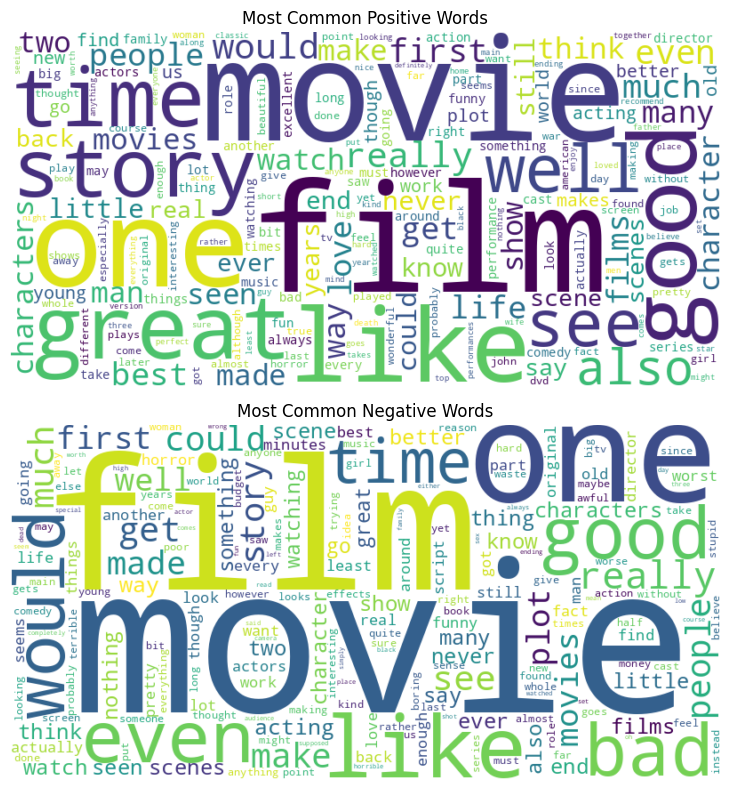

In [51]:
# Get most common words
pos_common_300 = Counter(pos_words).most_common(300)
neg_common_300 = Counter(neg_words).most_common(300)

pos_word_dict = dict(pos_common_300)
neg_word_dict = dict(neg_common_300)

# Generate a word cloud for positive words
pos_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(pos_word_dict)

# Generate a word cloud for negative words
neg_wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(neg_word_dict)



# Plot the word clouds
plt.figure(figsize=(20, 8))

plt.subplot(2, 1, 1)
plt.imshow(pos_wordcloud, interpolation='bilinear')
plt.title('Most Common Positive Words')
plt.axis('off')

plt.subplot(2, 1, 2)
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.title('Most Common Negative Words')
plt.axis('off')

plt.tight_layout()
plt.show()

### Assignment

In [ ]:
## Assignment based on n-gram validate if the sentiment is correct or not
# example 
# # when 
# review[1]= "movie was great but it can be better" | positive

In [52]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [53]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Alfred\AppData\Roaming\nltk_data...


True

In [54]:
analyzer = SentimentIntensityAnalyzer()

In [55]:
def get_sentiment(text):
    score = analyzer.polarity_scores(text)['compound']
    if score >= 0.05:
        return "good"
    elif score <= -0.05:
        return "bad"
    else:
        return "neutral"

In [56]:
## example
get_sentiment("Bad Movie")

'bad'

In [57]:
## example
get_sentiment("movie was great")

'good'

In [ ]:
# percentage (%) of correctness/ incorrectness


In [74]:
# t-test, chi-square (inferential)
# mean, median + contingency table (descriptive)

# Inferential Stats

In [61]:
# Goal 1 : # Check if review len differs significantly between positive and negative reviews

# two-sample hypothesis test
# Perform independent samples t-test
# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.

from scipy.stats import ttest_ind
# two-sample hypothesis test

# Split review lengths by sentiment
pos_lengths = df[df['sentiment'] == 'positive']['review_word_len']
neg_lengths = df[df['sentiment'] == 'negative']['review_word_len']

# two-sample hypothesis test
# Perform independent samples t-test
# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.
t_stat, p_value = ttest_ind(pos_lengths, neg_lengths, equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Calculate means and median for interpretation
print("Mean words (positive reviews):", pos_lengths.mean())
print("Mean words (negative reviews):", neg_lengths.mean())

print("Median words (positive reviews):", pos_lengths.median())
print("Median words (negative reviews):", neg_lengths.median())

if p_value < 0.05:
    print(f"\nWe reject H0 ({p_value:.4f} < 0.05 ), Average review length is different for positive and negative sentiment")
else:
    print("Fail to reject H0")

T-statistic: 2.208670012690372
P-value: 0.027202144656625855
Mean words (positive reviews): 232.84932
Mean words (negative reviews): 229.46456
Median words (positive reviews): 172.0
Median words (negative reviews): 174.0

We reject H0 (0.0272 < 0.05 ), Average review length is different for positive and negative sentiment


In [66]:
# testing on subset of data

df_subset = df.sample(n=1000, random_state=10)

# Split review lengths by sentiment
pos_lengths_sub = df_subset[df_subset['sentiment'] == 'positive']['review_word_len']
neg_lengths_sub = df_subset[df_subset['sentiment'] == 'negative']['review_word_len']

# two-sample hypothesis test
# Perform independent samples t-test
# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.
t_stat_sub, p_value_sub = ttest_ind(pos_lengths_sub, neg_lengths_sub, equal_var=False)

print("T-statistic:", t_stat_sub)
print("P-value:", p_value_sub)

# Calculate means and median for interpretation
print("Mean words (positive reviews):", pos_lengths_sub.mean())
print("Mean words (negative reviews):", neg_lengths_sub.mean())

print("Median words (positive reviews):", pos_lengths_sub.median())
print("Median words (negative reviews):", neg_lengths_sub.median())

if p_value_sub < 0.05:
    print(f"\nWe reject H0 ({p_value_sub:.4f} < 0.05 ), Average review length is different for positive and negative sentiment")
else:
    print(f"\nWe Fail to reject H0 (P-value of {p_value_sub:.4f} > 0.05 )")

T-statistic: 0.7794465378567212
P-value: 0.4359019526202907
Mean words (positive reviews): 226.5078431372549
Mean words (negative reviews): 218.80408163265307
Median words (positive reviews): 172.0
Median words (negative reviews): 170.0

We Fail to reject H0 (P-value of 0.4359 > 0.05 )


In [69]:
# Chi-Square Test of Independence

# H0 : Average review length (in words) is the same for positive and negative review
# H1 : Average review length (in words) is different between positive and negative reviews.

# Categorical
# word length : Not categorical
# Sentiment → categorical (positive, negative)
# Review length category → categorical (short, long)

df_subset['review_length_cat'] = df_subset['review_word_len'].apply(lambda x: 'short' if x <= 100 else 'long')

contingency = pd.crosstab(df_subset['review_length_cat'], df_subset['sentiment'])
print("Contingency Table:\n\n", contingency)

Contingency Table:

 sentiment          negative  positive
review_length_cat                    
long                    439       450
short                    51        60


In [70]:
from scipy.stats import chi2_contingency

In [72]:
chi2, p, _ , _ = chi2_contingency(contingency)
print("\nChi-Square Statistic:", chi2)
print("P-value:", p)


Chi-Square Statistic: 0.33869180582984193
P-value: 0.5605853114026997


In [73]:
if p < 0.05:
    print(f"\nWe reject H0 ({p :.4f} < 0.05 ), Average review length is different for positive and negative sentiment")
else:
    print(f"\nWe Fail to reject H0 (P-value of {p :.4f} > 0.05 )")


We Fail to reject H0 (P-value of 0.5606 > 0.05 )


## Conclusion : Average review length (in words) is different between positive and negative reviews.